MEMUAT DATASET...
Total data: 5072

TRAINING MODEL: BERAT
Jumlah data bersih: 5072
Data train: 4057
Data test : 1015


15:00:07 - cmdstanpy - INFO - Chain [1] start processing
15:00:08 - cmdstanpy - INFO - Chain [1] done processing



HASIL EVALUASI
----------------------------------------
MAE      : 1.78 Kg
RMSE     : 2.46 Kg
MAPE     : 13.62%
AKURASI  : 86.38%

TABEL PREDIKSI
------------------------------------------------------------
   Tanggal  Aktual  Prediksi  Error
2020-05-31    15.9     14.04   1.86
2020-05-31    15.9     14.04   1.86
2020-05-31    15.5     14.04   1.46
2020-05-31    15.6     14.04   1.56
2020-05-31    14.9     14.04   0.86
2020-05-31    14.8     14.04   0.76
2020-05-31    15.3     14.04   1.26
2020-05-31    13.2     14.04   0.84
2020-05-31    13.3     14.04   0.74
2020-05-31    13.4     14.04   0.64
2020-05-31    12.6     14.04   1.44
2020-05-31    12.1     14.04   1.94
2020-05-31    12.2     14.04   1.84
2020-05-31    12.0     14.04   2.04
2020-05-31    12.8     14.04   1.24


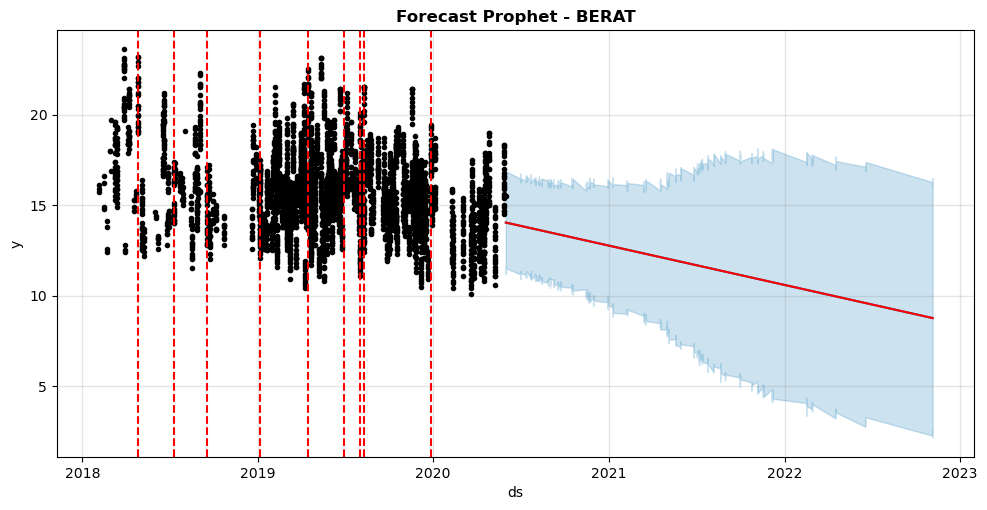

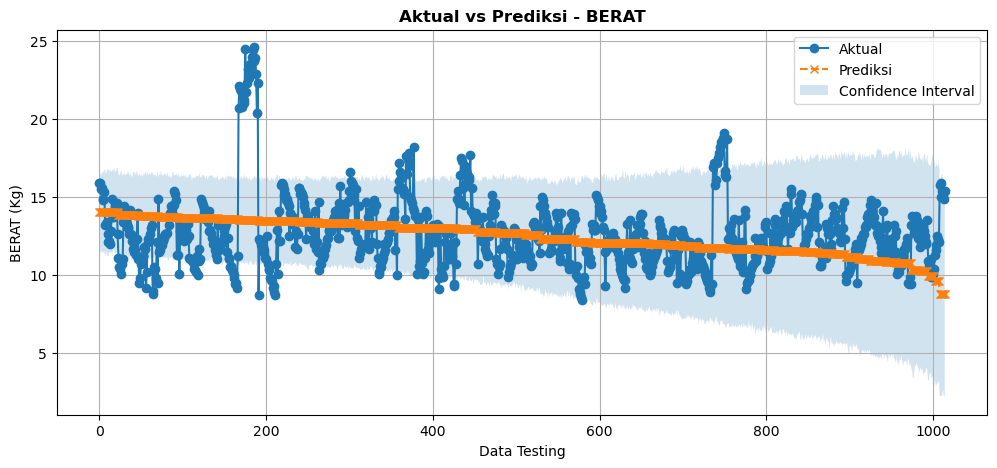


TRAIN FINAL MODEL...


15:00:09 - cmdstanpy - INFO - Chain [1] start processing
15:00:10 - cmdstanpy - INFO - Chain [1] done processing
15:00:10 - cmdstanpy - INFO - Chain [1] start processing


MODEL DISIMPAN: exported_models/prophet_berat.json

TRAINING MODEL: TINGGI
Jumlah data bersih: 5072
Data train: 4057
Data test : 1015


15:00:10 - cmdstanpy - INFO - Chain [1] done processing



HASIL EVALUASI
----------------------------------------
MAE      : 8.02 Cm
RMSE     : 9.51 Cm
MAPE     : 9.36%
AKURASI  : 90.64%

TABEL PREDIKSI
------------------------------------------------------------
   Tanggal  Aktual  Prediksi  Error
2020-05-31   104.1     95.45   8.65
2020-05-31   103.9     95.45   8.45
2020-05-31   102.9     95.45   7.45
2020-05-31   102.5     95.45   7.05
2020-05-31   100.1     95.45   4.65
2020-05-31    99.4     95.45   3.95
2020-05-31   101.0     95.45   5.55
2020-05-31    94.1     95.45   1.35
2020-05-31    94.9     95.45   0.55
2020-05-31    95.4     95.45   0.05
2020-05-31    92.0     95.45   3.45
2020-05-31    90.2     95.45   5.25
2020-05-31    91.5     95.45   3.95
2020-05-31    90.8     95.45   4.65
2020-05-31    92.6     95.45   2.85


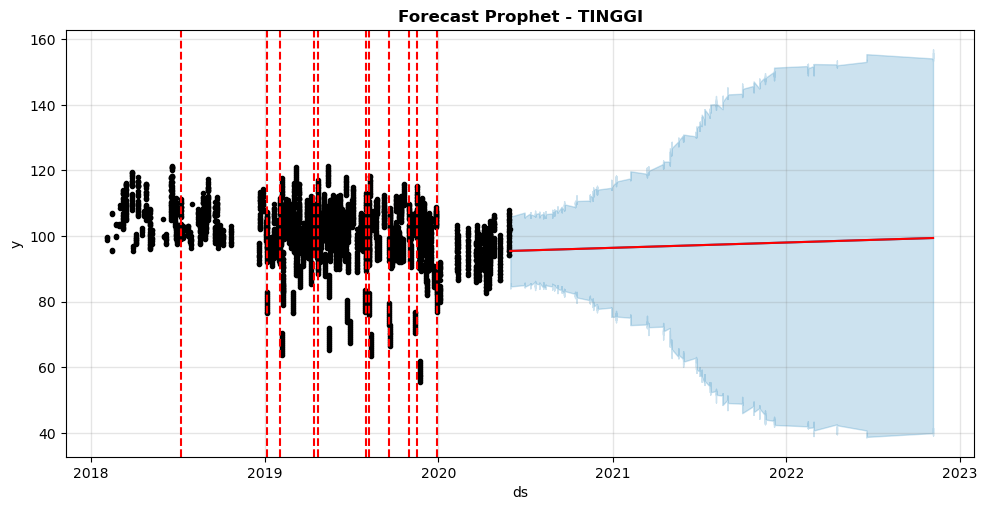

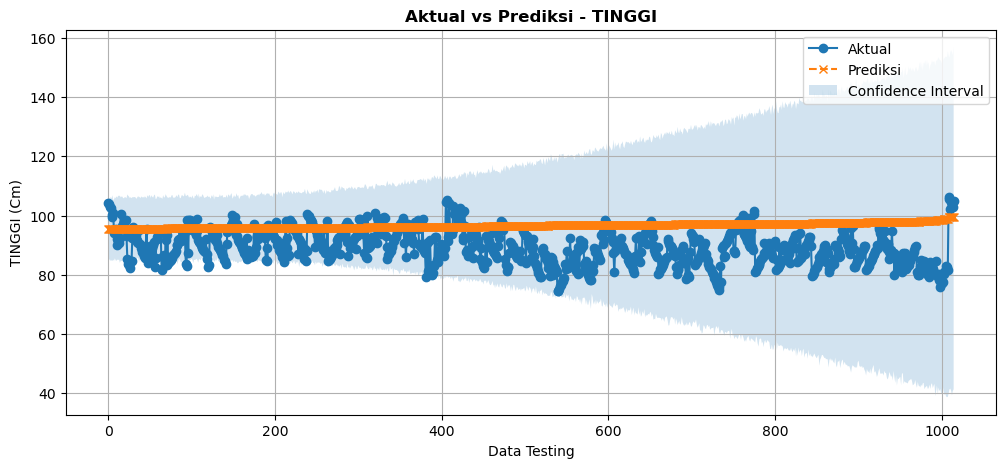

15:00:11 - cmdstanpy - INFO - Chain [1] start processing



TRAIN FINAL MODEL...


15:00:12 - cmdstanpy - INFO - Chain [1] done processing
15:00:12 - cmdstanpy - INFO - Chain [1] start processing


MODEL DISIMPAN: exported_models/prophet_tinggi.json

TRAINING MODEL: LINGKAR_KEPALA
Jumlah data bersih: 5072
Data train: 4057
Data test : 1015


15:00:13 - cmdstanpy - INFO - Chain [1] done processing



HASIL EVALUASI
----------------------------------------
MAE      : 2.69 Cm
RMSE     : 3.24 Cm
MAPE     : 5.73%
AKURASI  : 94.27%

TABEL PREDIKSI
------------------------------------------------------------
   Tanggal  Aktual  Prediksi  Error
2020-05-31    49.3     49.27   0.03
2020-05-31    49.2     49.27   0.07
2020-05-31    49.2     49.27   0.07
2020-05-31    49.0     49.27   0.27
2020-05-31    48.8     49.27   0.47
2020-05-31    48.8     49.27   0.47
2020-05-31    48.9     49.27   0.37
2020-05-31    48.4     49.27   0.87
2020-05-31    48.4     49.27   0.87
2020-05-31    48.5     49.27   0.77
2020-05-31    48.3     49.27   0.97
2020-05-31    48.0     49.27   1.27
2020-05-31    48.1     49.27   1.17
2020-05-31    48.1     49.27   1.17
2020-05-31    48.2     49.27   1.07


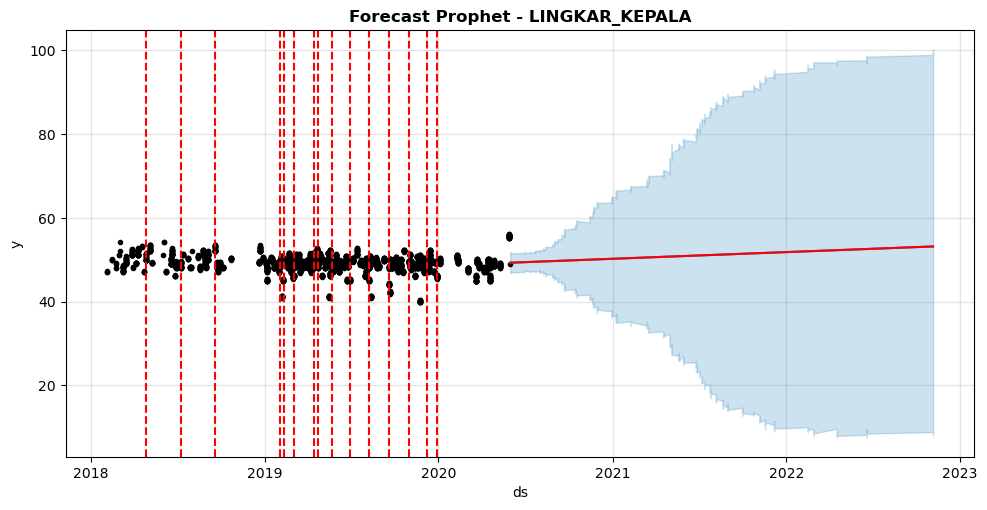

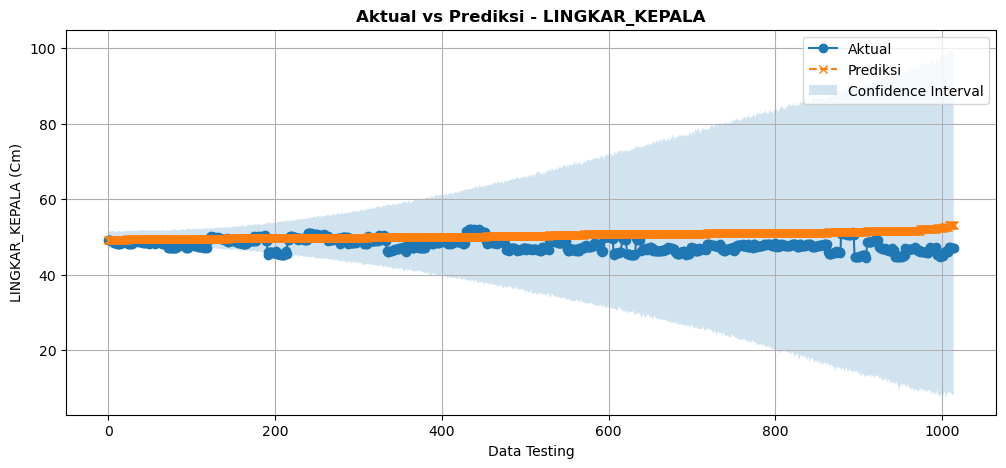

15:00:13 - cmdstanpy - INFO - Chain [1] start processing



TRAIN FINAL MODEL...


15:00:15 - cmdstanpy - INFO - Chain [1] done processing


MODEL DISIMPAN: exported_models/prophet_lingkar_kepala.json

SEMUA MODEL BERHASIL DIEKSPOR

Metadata: exported_models/metadata.json

BERAT
Akurasi : 86.378%
Data    : 5072

TINGGI
Akurasi : 90.638%
Data    : 5072

LINGKAR_KEPALA
Akurasi : 94.267%
Data    : 5072


In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import logging
import warnings
import os
import json

from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from prophet.serialize import model_to_json

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# ============================================================
# 1. LOAD DATASET
# ============================================================

print("="*60)
print("MEMUAT DATASET...")
print("="*60)

df = pd.read_excel(
    r'D:\SKRIPSI\Sistem_posyandu\DATA FINAL POSYANDU.xlsx'
)

# Rapikan kolom
df.columns = df.columns.str.strip().str.lower()

# Format tanggal
df['tanggal_ukur'] = pd.to_datetime(df['tanggal_ukur'])

# Hapus data kosong penting
df = df.dropna(subset=['nama_anak', 'tanggal_ukur'])

# Urutkan
df = df.sort_values(['nama_anak', 'tanggal_ukur'])

# Hapus duplikat
df = df.drop_duplicates()

print(f"Total data: {len(df)}")

# ============================================================
# 2. DAFTAR INDIKATOR
# ============================================================

daftar_indikator = [
    'berat',
    'tinggi',
    'lingkar_kepala'
]

# Folder model
os.makedirs('exported_models', exist_ok=True)

# Metadata
metadata = {}

# ============================================================
# 3. LOOP TRAINING PER INDIKATOR
# ============================================================

for metrik in daftar_indikator:

    print("\n" + "="*70)
    print(f"TRAINING MODEL: {metrik.upper()}")
    print("="*70)

    # ========================================================
    # AMBIL DATA
    # ========================================================

    data = df[['tanggal_ukur', metrik]].copy()

    data = data.rename(columns={
        'tanggal_ukur': 'ds',
        metrik: 'y'
    })

    # Hapus NaN
    data = data.dropna()

    # Urutkan
    data = data.sort_values('ds')

    # ========================================================
    # FILTER NILAI TIDAK MASUK AKAL
    # ========================================================

    if metrik == 'berat':
        data = data[(data['y'] >= 2) & (data['y'] <= 40)]

    elif metrik == 'tinggi':
        data = data[(data['y'] >= 30) & (data['y'] <= 130)]

    elif metrik == 'lingkar_kepala':
        data = data[(data['y'] >= 20) & (data['y'] <= 60)]

    print(f"Jumlah data bersih: {len(data)}")

    # ========================================================
    # SPLIT TRAIN TEST
    # ========================================================

    train_size = int(len(data) * 0.8)

    train = data.iloc[:train_size]
    test = data.iloc[train_size:]

    print(f"Data train: {len(train)}")
    print(f"Data test : {len(test)}")

    # ========================================================
    # TRAIN MODEL PROPHET
    # ========================================================

    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        changepoint_range=0.9
    )

    model.fit(train)

    # ========================================================
    # PREDIKSI
    # ========================================================

    future = test[['ds']]

    forecast = model.predict(future)

    # ========================================================
    # EVALUASI
    # ========================================================

    y_true = test['y'].values
    y_pred = forecast['yhat'].values

    mae = np.mean(np.abs(y_true - y_pred))

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    accuracy = 100 - mape

    satuan = "Kg" if metrik == 'berat' else "Cm"

    print("\nHASIL EVALUASI")
    print("-"*40)
    print(f"MAE      : {mae:.2f} {satuan}")
    print(f"RMSE     : {rmse:.2f} {satuan}")
    print(f"MAPE     : {mape:.2f}%")
    print(f"AKURASI  : {accuracy:.2f}%")

    # ========================================================
    # TABEL HASIL
    # ========================================================

    hasil = pd.DataFrame({
        'Tanggal': test['ds'].dt.strftime('%Y-%m-%d'),
        'Aktual': np.round(y_true, 2),
        'Prediksi': np.round(y_pred, 2)
    })

    hasil['Error'] = np.round(
        np.abs(hasil['Aktual'] - hasil['Prediksi']),
        2
    )

    print("\nTABEL PREDIKSI")
    print("-"*60)
    print(hasil.head(15).to_string(index=False))

    # ========================================================
    # GRAFIK FORECAST
    # ========================================================

    fig1 = model.plot(forecast, figsize=(10, 5))

    add_changepoints_to_plot(
        fig1.gca(),
        model,
        forecast
    )

    plt.title(
        f'Forecast Prophet - {metrik.upper()}',
        fontweight='bold'
    )

    plt.grid(True)
    plt.show()

    # ========================================================
    # GRAFIK AKTUAL VS PREDIKSI
    # ========================================================

    plt.figure(figsize=(12, 5))

    plt.plot(
        range(len(test)),
        y_true,
        marker='o',
        label='Aktual'
    )

    plt.plot(
        range(len(test)),
        y_pred,
        marker='x',
        linestyle='--',
        label='Prediksi'
    )

    plt.fill_between(
        range(len(test)),
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        alpha=0.2,
        label='Confidence Interval'
    )

    plt.title(
        f'Aktual vs Prediksi - {metrik.upper()}',
        fontweight='bold'
    )

    plt.xlabel('Data Testing')
    plt.ylabel(f'{metrik.upper()} ({satuan})')

    plt.legend()
    plt.grid(True)

    plt.show()

    # ========================================================
    # TRAIN FINAL MODEL (SEMUA DATA)
    # ========================================================

    print("\nTRAIN FINAL MODEL...")

    model_final = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        changepoint_range=0.9
    )

    model_final.fit(data)

    # ========================================================
    # EXPORT MODEL
    # ========================================================

    model_path = f'exported_models/prophet_{metrik}.json'

    with open(model_path, 'w') as f:
        json.dump(
            model_to_json(model_final),
            f
        )

    print(f"MODEL DISIMPAN: {model_path}")

    # ========================================================
    # METADATA
    # ========================================================

    metadata[metrik] = {
        "model_file": model_path,
        "jumlah_data": int(len(data)),
        "last_training_date": str(data['ds'].max().date()),
        "mae": round(float(mae), 3),
        "rmse": round(float(rmse), 3),
        "mape": round(float(mape), 3),
        "accuracy": round(float(accuracy), 3),
        "satuan": satuan
    }

# ============================================================
# 4. SIMPAN METADATA
# ============================================================

metadata_path = 'exported_models/metadata.json'

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print("\n" + "="*60)
print("SEMUA MODEL BERHASIL DIEKSPOR")
print("="*60)

print(f"\nMetadata: {metadata_path}")

for k, v in metadata.items():
    print(f"\n{k.upper()}")
    print(f"Akurasi : {v['accuracy']}%")
    print(f"Data    : {v['jumlah_data']}")

MEMUAT DATASET...
Total data: 5072

ANALISIS INDIKATOR : BERAT

HASIL GLOBAL
--------------------------------------------------
Jumlah Anak : 259
MAE          : 0.55 Kg
RMSE         : 0.61 Kg
MAPE         : 3.33%
AKURASI      : 96.67%

STUDI KASUS TERBAIK
Nama Anak : BILQIS FATIMATUS
MAPE       : 0.34%
Akurasi    : 99.66%
Status     : Risiko Berat Badan Lebih

TABEL PREDIKSI
   Tanggal  Aktual  Prediksi  Error
2021-01-09    19.0     19.11   0.11
2021-02-09    19.3     19.31   0.01
2021-03-09    19.5     19.50   0.00
2021-04-09    19.7     19.71   0.01
2021-05-09    19.7     19.91   0.21


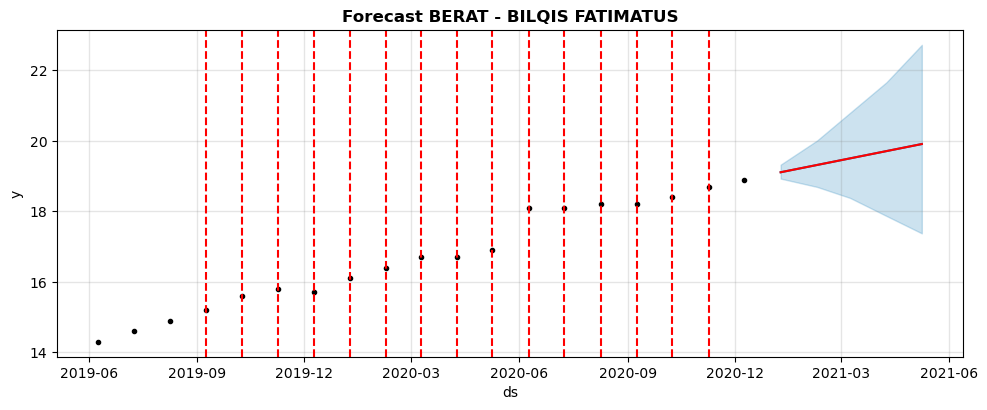

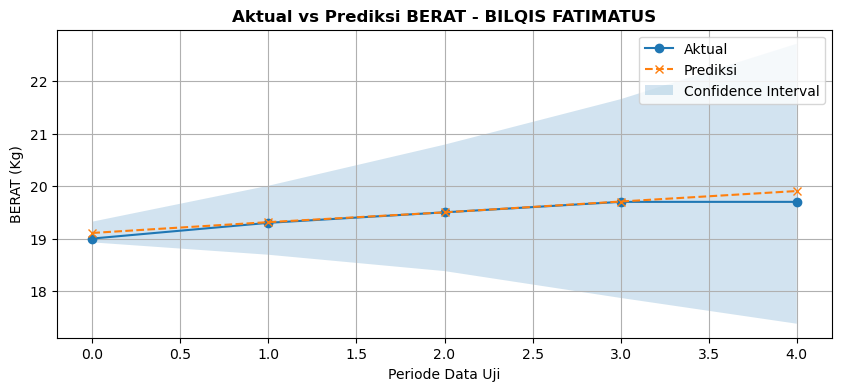


STUDI KASUS MENENGAH
Nama Anak : FERDINAND DAFFA
MAPE       : 3.31%
Akurasi    : 96.69%
Status     : BB Kurang (Underweight)

TABEL PREDIKSI
   Tanggal  Aktual  Prediksi  Error
2021-05-26    14.6      14.5    0.1
2021-06-26    15.0      14.5    0.5
2021-07-26    15.1      14.5    0.6
2021-08-26    15.1      14.5    0.6
2021-09-26    15.2      14.5    0.7


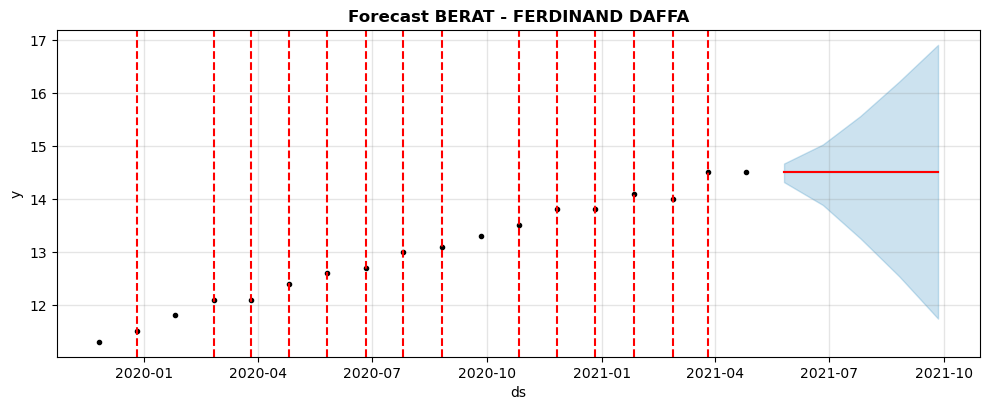

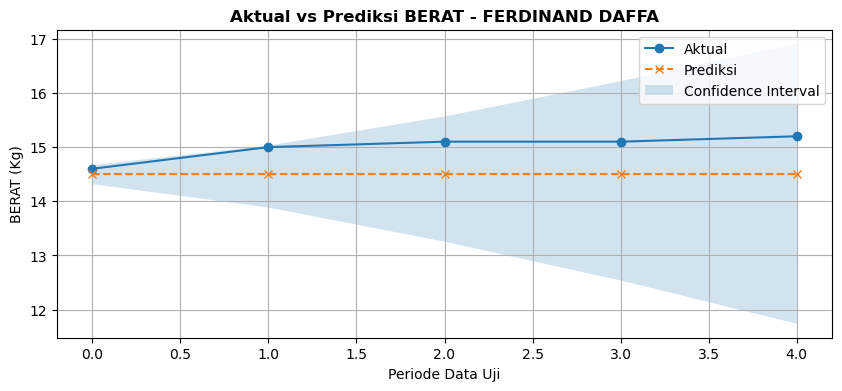


STUDI KASUS TERBURUK
Nama Anak : NAUZAN AZMI R
MAPE       : 20.06%
Akurasi    : 79.94%
Status     : BB Kurang (Underweight)

TABEL PREDIKSI
   Tanggal  Aktual  Prediksi  Error
2020-11-27    16.2     18.04   1.84
2020-12-27    16.5     19.24   2.74
2021-01-27    17.5     20.48   2.98
2021-02-27    17.1     21.72   4.62
2021-03-27    17.8     22.84   5.04


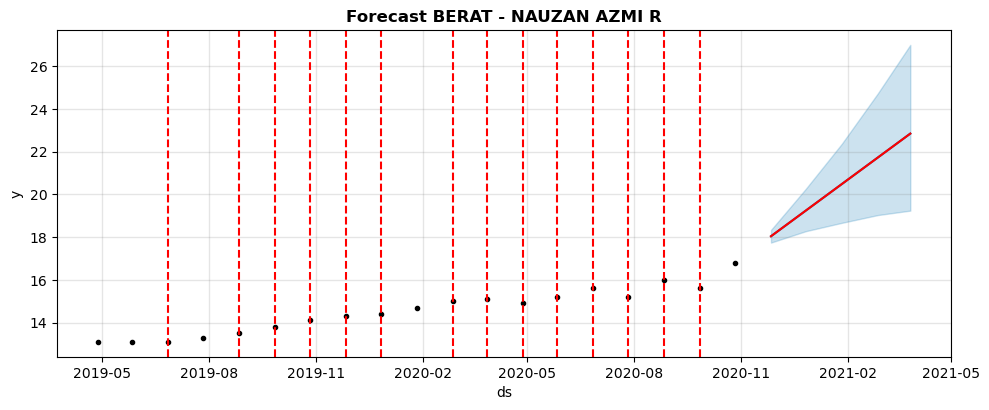

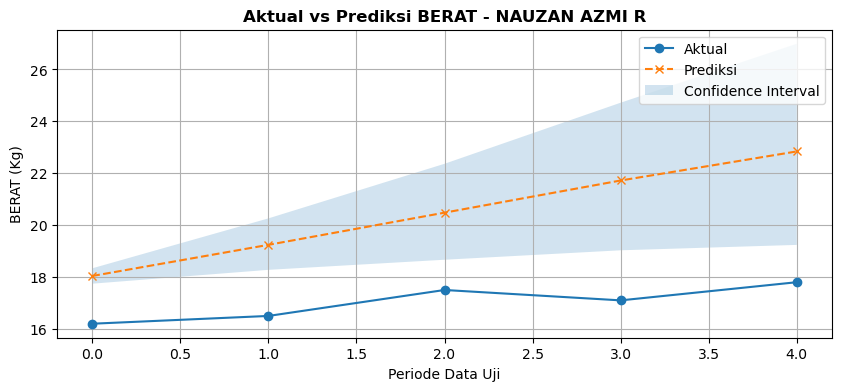


TRAIN FINAL MODEL
MODEL DISIMPAN : exported_models/prophet_berat.json

ANALISIS INDIKATOR : TINGGI

HASIL GLOBAL
--------------------------------------------------
Jumlah Anak : 259
MAE          : 0.71 Cm
RMSE         : 0.78 Cm
MAPE         : 0.69%
AKURASI      : 99.31%

STUDI KASUS TERBAIK
Nama Anak : ISTIANA ALFATUN NISA
MAPE       : 0.01%
Akurasi    : 99.99%
Status     : Normal

TABEL PREDIKSI
   Tanggal  Aktual  Prediksi  Error
2020-09-02   103.8    103.80   0.00
2020-10-02   104.4    104.38   0.02
2020-11-02   105.0    104.98   0.02


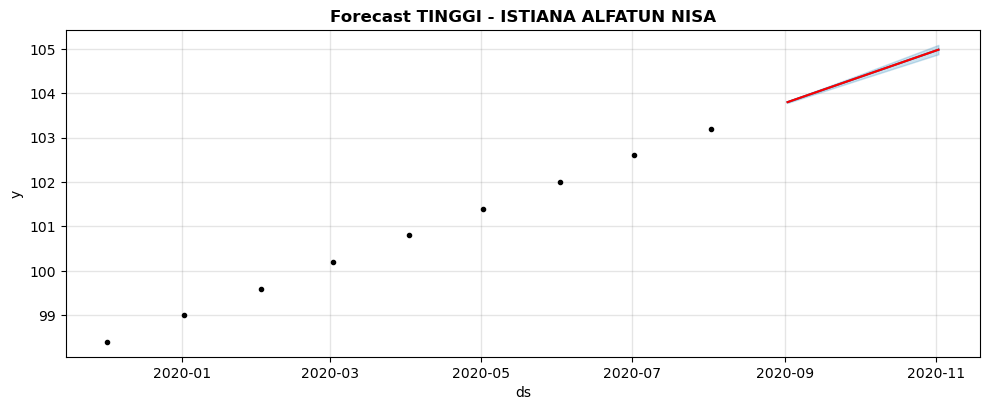

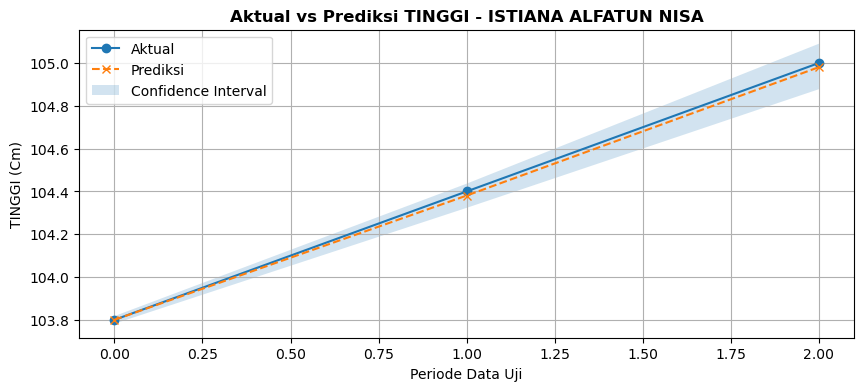


STUDI KASUS MENENGAH
Nama Anak : M. RASKA
MAPE       : 0.70%
Akurasi    : 99.30%
Status     : Normal

TABEL PREDIKSI
   Tanggal  Aktual  Prediksi  Error
2021-07-12   101.0    101.07   0.07
2021-08-12   101.6    101.97   0.37
2021-09-12   102.3    102.87   0.57
2021-10-12   102.5    103.74   1.24
2021-11-12   103.3    104.64   1.34


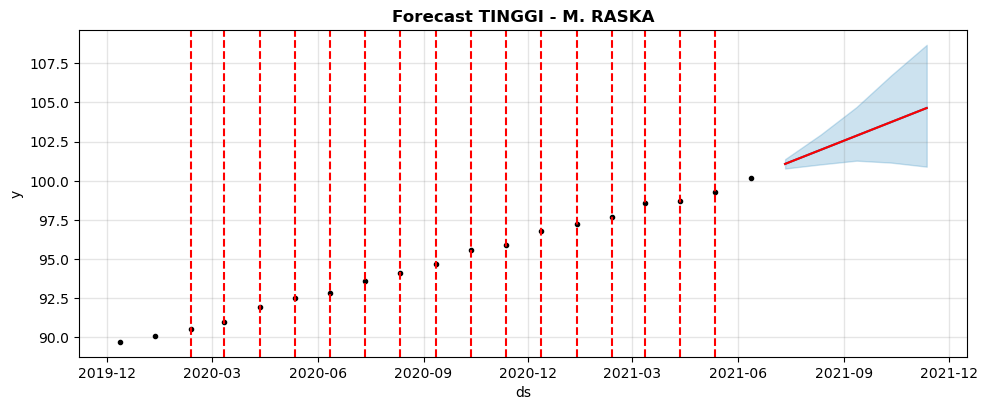

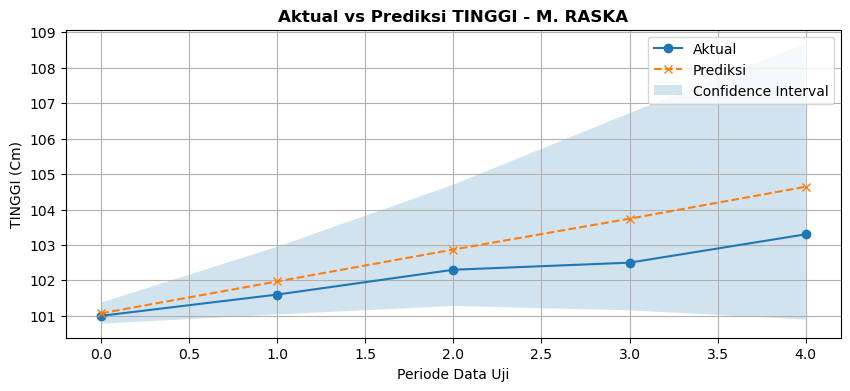


STUDI KASUS TERBURUK
Nama Anak : ADITYA CHANDRA TAMA
MAPE       : 6.37%
Akurasi    : 93.63%
Status     : Pendek (Stunted)

TABEL PREDIKSI
   Tanggal  Aktual  Prediksi  Error
2020-11-15   104.2    107.78   3.58
2020-12-15   105.7    110.08   4.38
2021-01-15   105.7    112.45   6.75
2021-02-15   106.6    114.83   8.23
2021-03-15   106.2    116.98  10.78


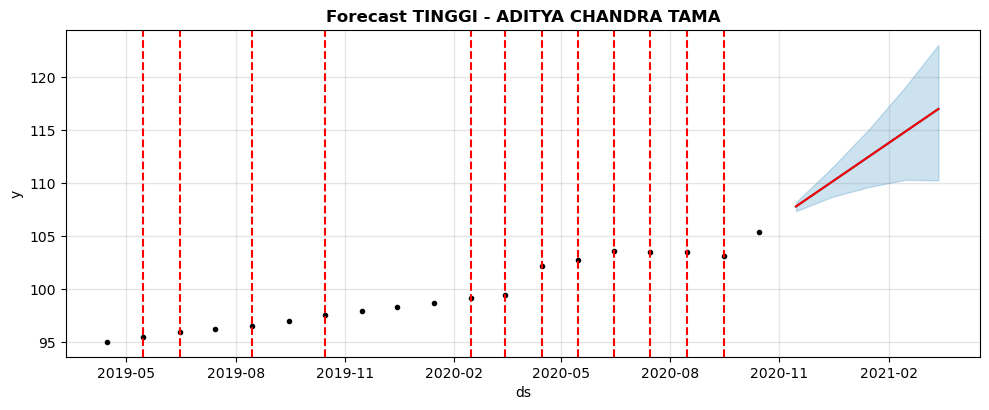

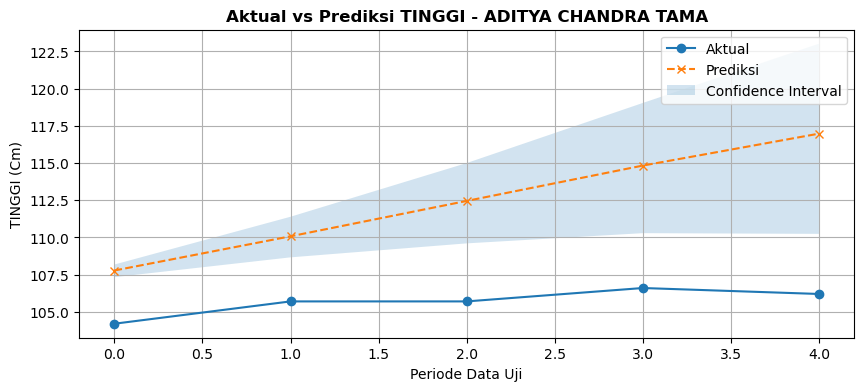


TRAIN FINAL MODEL
MODEL DISIMPAN : exported_models/prophet_tinggi.json

ANALISIS INDIKATOR : LINGKAR_KEPALA

HASIL GLOBAL
--------------------------------------------------
Jumlah Anak : 259
MAE          : 0.50 Cm
RMSE         : 0.55 Cm
MAPE         : 1.03%
AKURASI      : 98.97%

STUDI KASUS TERBAIK
Nama Anak : KIARA ARSYILA KHANZA
MAPE       : 0.00%
Akurasi    : 100.00%
Status     : Normal

TABEL PREDIKSI
   Tanggal  Aktual  Prediksi  Error
2021-01-12    49.5      49.5    0.0
2021-02-12    49.5      49.5    0.0
2021-03-12    49.5      49.5    0.0
2021-04-12    49.5      49.5    0.0
2021-05-12    49.5      49.5    0.0


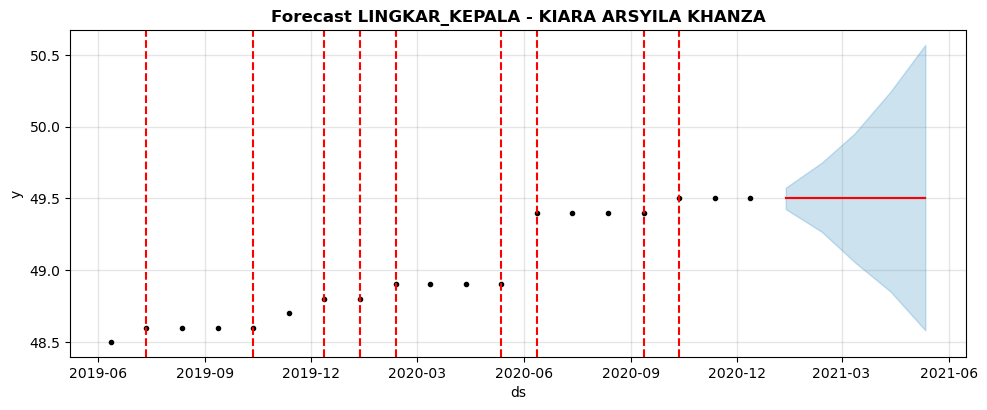

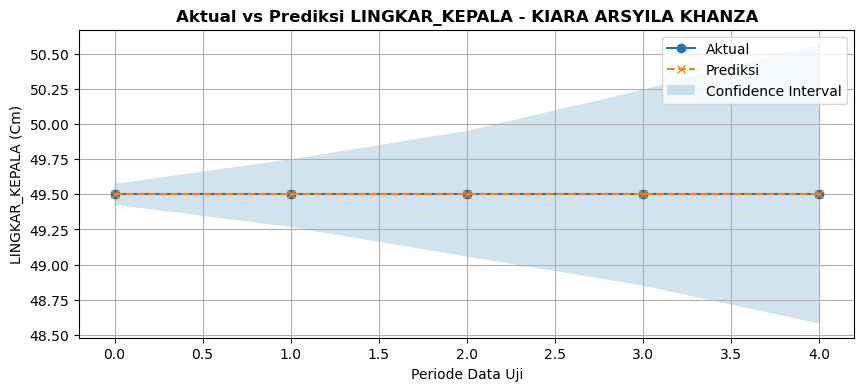


STUDI KASUS MENENGAH
Nama Anak : M. HAIRUL AZMI
MAPE       : 1.03%
Akurasi    : 98.97%
Status     : Normal

TABEL PREDIKSI
   Tanggal  Aktual  Prediksi  Error
2022-02-08    47.1     47.30   0.20
2022-03-08    47.1     47.48   0.38
2022-04-08    47.1     47.68   0.58
2022-05-08    47.1     47.87   0.77


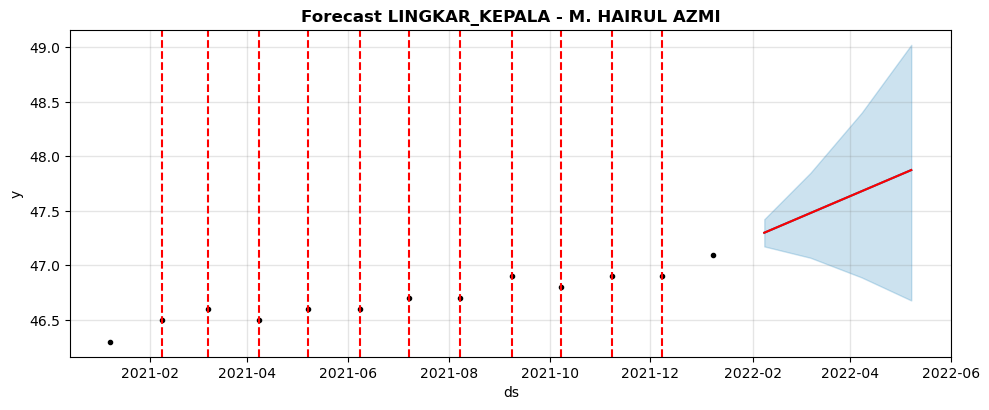

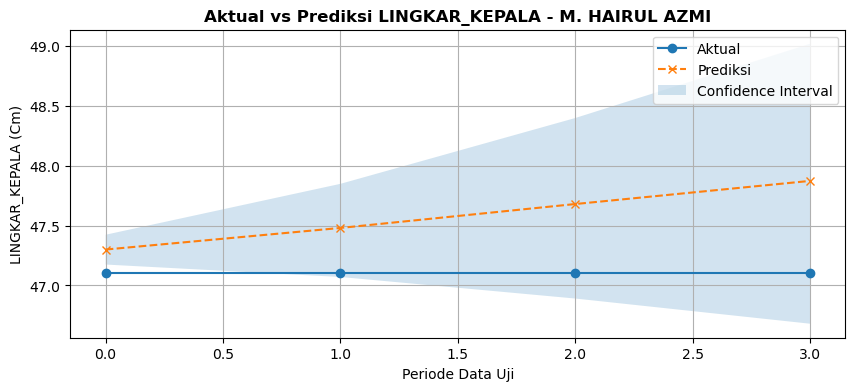


STUDI KASUS TERBURUK
Nama Anak : M. HAMDAN ALKAHFI
MAPE       : 5.65%
Akurasi    : 94.35%
Status     : Normal

TABEL PREDIKSI
   Tanggal  Aktual  Prediksi  Error
2020-10-22    51.3     52.47   1.17
2020-11-22    51.8     53.37   1.57
2020-12-22    51.0     54.24   3.24
2021-01-22    51.8     55.14   3.34
2021-02-22    50.9     56.04   5.14


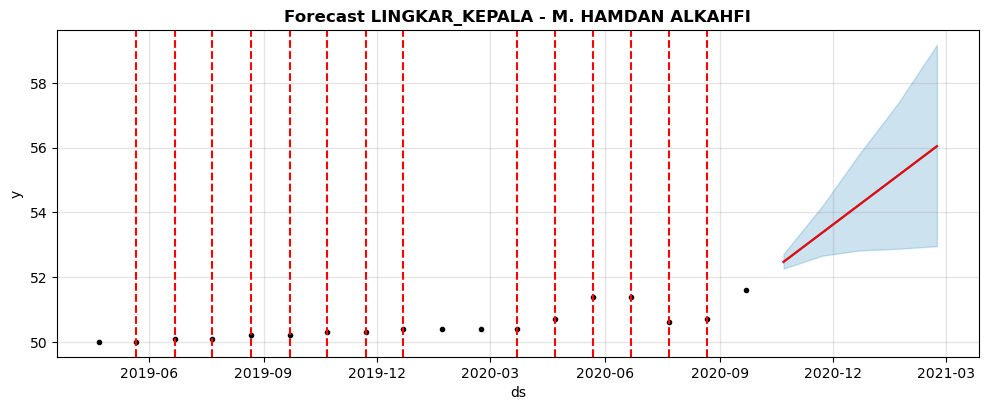

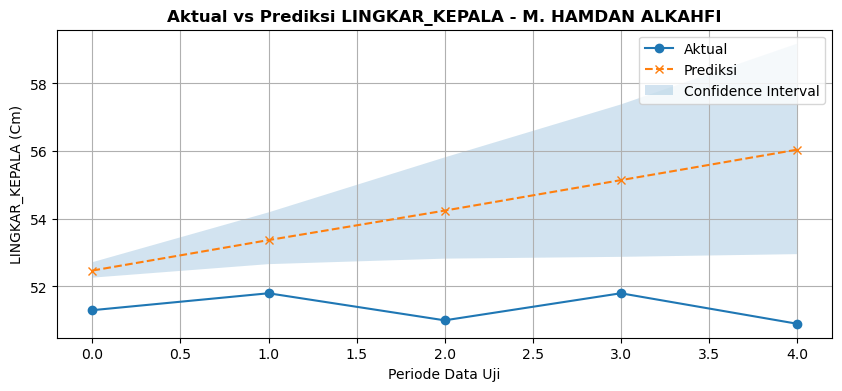


TRAIN FINAL MODEL
MODEL DISIMPAN : exported_models/prophet_lingkar_kepala.json

SEMUA MODEL BERHASIL DIEKSPOR

Metadata : exported_models/metadata.json

BERAT
Akurasi : 96.668%
Jumlah Anak : 259

TINGGI
Akurasi : 99.308%
Jumlah Anak : 259

LINGKAR_KEPALA
Akurasi : 98.97%
Jumlah Anak : 259


In [4]:
%matplotlib inline

import pandas as pd
import numpy as np
import logging
import warnings
import random
import os
import json

from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from prophet.serialize import model_to_json

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# =============================================================
# FUNGSI STATUS GIZI
# =============================================================

def klasifikasi_status_gizi(z_score, indikator):

    if indikator == 'BB/U':

        if z_score < -3:
            return "BB Sangat Kurang (Severe Underweight)"

        elif -3 <= z_score < -2:
            return "BB Kurang (Underweight)"

        elif -2 <= z_score <= 1:
            return "Berat Badan Normal"

        else:
            return "Risiko Berat Badan Lebih"

    elif indikator == 'TB/U':

        if z_score < -3:
            return "Sangat Pendek (Severe Stunted)"

        elif -3 <= z_score < -2:
            return "Pendek (Stunted)"

        elif -2 <= z_score <= 3:
            return "Normal"

        else:
            return "Tinggi"

    elif indikator == 'LK/U':

        if z_score < -2:
            return "Mikrosefali"

        elif -2 <= z_score <= 2:
            return "Normal"

        else:
            return "Makrosefali"

    return "Tidak Diketahui"

# =============================================================
# LOAD DATASET
# =============================================================

print("="*60)
print("MEMUAT DATASET...")
print("="*60)

df = pd.read_excel('D:\SKRIPSI\Sistem_posyandu\DATA_FINAL_1_POSYANDU_FIX.xlsx')

# Rapikan nama kolom
df.columns = df.columns.str.strip().str.lower()

# Format tanggal
df['tanggal_ukur'] = pd.to_datetime(df['tanggal_ukur'])

# Hapus data kosong penting
df = df.dropna(subset=['nama_anak', 'tanggal_ukur'])

# Urutkan data
df = df.sort_values(['nama_anak', 'tanggal_ukur'])

# Hapus duplikat
df = df.drop_duplicates()

print(f"Total data: {len(df)}")

# =============================================================
# DAFTAR ANAK & INDIKATOR
# =============================================================

daftar_anak = df['nama_anak'].unique()

daftar_indikator = [
    'berat',
    'tinggi',
    'lingkar_kepala'
]

# =============================================================
# FOLDER OUTPUT
# =============================================================

os.makedirs('exported_models', exist_ok=True)

metadata = {}

# =============================================================
# LOOP PER INDIKATOR
# =============================================================

for metrik in daftar_indikator:

    print("\n" + "="*80)
    print(f"ANALISIS INDIKATOR : {metrik.upper()}")
    print("="*80)

    hasil_evaluasi_global = []

    # =========================================================
    # LOOP PER ANAK
    # =========================================================

    for nama in daftar_anak:

        df_anak = df[
            df['nama_anak'] == nama
        ].copy()

        df_anak = df_anak.sort_values(
            'tanggal_ukur'
        )

        # =====================================================
        # FORMAT PROPHET
        # =====================================================

        if metrik not in df_anak.columns:
            continue

        df_prophet = df_anak[
            ['tanggal_ukur', metrik]
        ].copy()

        df_prophet = df_prophet.rename(
            columns={
                'tanggal_ukur': 'ds',
                metrik: 'y'
            }
        )

        # Hapus NaN
        df_prophet = df_prophet.dropna()

        # =====================================================
        # FILTER DATA TIDAK VALID
        # =====================================================

        df_prophet = df_prophet[
            df_prophet['y'] > 0
        ]

        # Filter biologis
        if metrik == 'berat':

            df_prophet = df_prophet[
                (df_prophet['y'] >= 2) &
                (df_prophet['y'] <= 40)
            ]

        elif metrik == 'tinggi':

            df_prophet = df_prophet[
                (df_prophet['y'] >= 30) &
                (df_prophet['y'] <= 130)
            ]

        elif metrik == 'lingkar_kepala':

            df_prophet = df_prophet[
                (df_prophet['y'] >= 20) &
                (df_prophet['y'] <= 60)
            ]

        # Hapus duplikat tanggal
        df_prophet = df_prophet.drop_duplicates(
            subset=['ds']
        )

        # Urutkan tanggal
        df_prophet = df_prophet.sort_values('ds')

        # Minimal data
        if len(df_prophet) < 10:
            continue

        # Variasi data harus ada
        if df_prophet['y'].nunique() < 2:
            continue

        # =====================================================
        # SPLIT TRAIN TEST
        # =====================================================

        train_size = int(
            len(df_prophet) * 0.8
        )

        data_latih = df_prophet.iloc[:train_size]

        data_uji = df_prophet.iloc[train_size:]

        if len(data_uji) < 2:
            continue

        # =====================================================
        # TRAIN MODEL
        # =====================================================

        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.5,
            changepoint_range=0.95
        )

        try:

            model.fit(data_latih)

        except Exception as e:

            print(
                f"Model gagal untuk {nama}"
            )

            continue

        # =====================================================
        # PREDIKSI
        # =====================================================

        forecast = model.predict(
            data_uji[['ds']]
        )

        y_true = data_uji['y'].values

        y_pred = forecast['yhat'].values

        # =====================================================
        # EVALUASI
        # =====================================================

        error = y_true - y_pred

        mae = np.mean(np.abs(error))

        rmse = np.sqrt(
            np.mean(error**2)
        )

        mape = np.mean(
            np.abs(
                error /
                np.where(y_true == 0, 1, y_true)
            )
        ) * 100

        hasil_evaluasi_global.append({

            'Nama': nama,

            'MAE': mae,

            'RMSE': rmse,

            'MAPE': mape
        })

    # =========================================================
    # CEK HASIL
    # =========================================================

    if len(hasil_evaluasi_global) == 0:

        print("Tidak ada data valid")

        continue

    df_eval = pd.DataFrame(
        hasil_evaluasi_global
    )

    # =========================================================
    # HASIL GLOBAL
    # =========================================================

    rata_mae = df_eval['MAE'].mean()

    rata_rmse = df_eval['RMSE'].mean()

    rata_mape = df_eval['MAPE'].mean()

    akurasi = 100 - rata_mape

    satuan = (
        "Kg"
        if metrik == 'berat'
        else "Cm"
    )

    print("\nHASIL GLOBAL")
    print("-"*50)

    print(
        f"Jumlah Anak : {len(df_eval)}"
    )

    print(
        f"MAE          : {rata_mae:.2f} {satuan}"
    )

    print(
        f"RMSE         : {rata_rmse:.2f} {satuan}"
    )

    print(
        f"MAPE         : {rata_mape:.2f}%"
    )

    print(
        f"AKURASI      : {akurasi:.2f}%"
    )

    # =========================================================
    # STUDI KASUS
    # =========================================================

    idx_terbaik = df_eval['MAPE'].idxmin()

    idx_terburuk = df_eval['MAPE'].idxmax()

    df_eval['selisih_mean'] = abs(
        df_eval['MAPE'] - rata_mape
    )

    idx_menengah = df_eval[
        'selisih_mean'
    ].idxmin()

    studi_kasus = {

        'TERBAIK':
        df_eval.loc[idx_terbaik, 'Nama'],

        'MENENGAH':
        df_eval.loc[idx_menengah, 'Nama'],

        'TERBURUK':
        df_eval.loc[idx_terburuk, 'Nama']
    }

    # =========================================================
    # KODE WHO
    # =========================================================

    if metrik == 'berat':

        kode_ind = 'BB/U'

    elif metrik == 'tinggi':

        kode_ind = 'TB/U'

    else:

        kode_ind = 'LK/U'

    # =========================================================
    # VISUALISASI 3 STUDI KASUS
    # =========================================================

    for kategori, nama_target in studi_kasus.items():

        print("\n" + "="*70)

        print(
            f"STUDI KASUS {kategori}"
        )

        print("="*70)

        eval_anak = df_eval[
            df_eval['Nama'] == nama_target
        ].iloc[0]

        df_anak = df[
            df['nama_anak'] == nama_target
        ].copy()

        df_anak = df_anak.sort_values(
            'tanggal_ukur'
        )

        df_prophet = df_anak[
            ['tanggal_ukur', metrik]
        ].copy()

        df_prophet = df_prophet.rename(
            columns={
                'tanggal_ukur': 'ds',
                metrik: 'y'
            }
        )

        df_prophet = df_prophet.dropna()

        # Split
        train_size = int(
            len(df_prophet) * 0.8
        )

        data_latih = df_prophet.iloc[:train_size]

        data_uji = df_prophet.iloc[train_size:]

        # Model
        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.5,
            changepoint_range=0.95
        )

        model.fit(data_latih)

        forecast = model.predict(
            data_uji[['ds']]
        )

        # =====================================================
        # STATUS GIZI SIMULASI
        # =====================================================

        z_score = round(
            random.uniform(-3, 1.5),
            2
        )

        status_gizi = klasifikasi_status_gizi(
            z_score,
            kode_ind
        )

        print(f"Nama Anak : {nama_target}")

        print(
            f"MAPE       : {eval_anak['MAPE']:.2f}%"
        )

        print(
            f"Akurasi    : {100 - eval_anak['MAPE']:.2f}%"
        )

        print(
            f"Status     : {status_gizi}"
        )

        # =====================================================
        # TABEL
        # =====================================================

        hasil = pd.DataFrame({

            'Tanggal':
            data_uji['ds'].dt.strftime(
                '%Y-%m-%d'
            ),

            'Aktual':
            np.round(
                data_uji['y'].values,
                2
            ),

            'Prediksi':
            np.round(
                forecast['yhat'].values,
                2
            )
        })

        hasil['Error'] = np.round(

            np.abs(
                hasil['Aktual'] -
                hasil['Prediksi']
            ),

            2
        )

        print("\nTABEL PREDIKSI")

        print(hasil.to_string(index=False))

        # =====================================================
        # GRAFIK FORECAST
        # =====================================================

        fig1 = model.plot(
            forecast,
            figsize=(10, 4)
        )

        add_changepoints_to_plot(
            fig1.gca(),
            model,
            forecast
        )

        plt.title(
            f'Forecast {metrik.upper()} - {nama_target}',
            fontweight='bold'
        )

        plt.grid(True)

        plt.show()

        # =====================================================
        # GRAFIK AKTUAL VS PREDIKSI
        # =====================================================

        plt.figure(figsize=(10, 4))

        plt.plot(

            range(len(data_uji)),

            data_uji['y'],

            marker='o',

            label='Aktual'
        )

        plt.plot(

            range(len(data_uji)),

            forecast['yhat'],

            marker='x',

            linestyle='--',

            label='Prediksi'
        )

        plt.fill_between(

            range(len(data_uji)),

            forecast['yhat_lower'],

            forecast['yhat_upper'],

            alpha=0.2,

            label='Confidence Interval'
        )

        plt.title(

            f'Aktual vs Prediksi {metrik.upper()} - {nama_target}',

            fontweight='bold'
        )

        plt.xlabel(
            'Periode Data Uji'
        )

        plt.ylabel(
            f'{metrik.upper()} ({satuan})'
        )

        plt.legend()

        plt.grid(True)

        plt.show()

    # =========================================================
    # TRAIN FINAL MODEL
    # =========================================================

    print("\nTRAIN FINAL MODEL")

    data_all = df[
        ['tanggal_ukur', metrik]
    ].copy()

    data_all = data_all.rename(
        columns={
            'tanggal_ukur': 'ds',
            metrik: 'y'
        }
    )

    data_all = data_all.dropna()

    model_final = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.005,
        changepoint_range=0.8,
        growth='linear'
    )

    model_final.fit(data_all)

    # =========================================================
    # EXPORT MODEL
    # =========================================================

    model_path = (
        f'exported_models/prophet_{metrik}.json'
    )

    with open(model_path, 'w') as f:

        json.dump(
            model_to_json(model_final),
            f
        )

    print(
        f"MODEL DISIMPAN : {model_path}"
    )

    # =========================================================
    # METADATA
    # =========================================================

    metadata[metrik] = {

        "model_file": model_path,

        "jumlah_anak":
        int(len(df_eval)),

        "akurasi":
        round(float(akurasi), 3),

        "mae":
        round(float(rata_mae), 3),

        "rmse":
        round(float(rata_rmse), 3),

        "mape":
        round(float(rata_mape), 3),

        "satuan":
        satuan
    }

# =============================================================
# SIMPAN METADATA
# =============================================================

metadata_path = (
    'exported_models/metadata.json'
)

with open(metadata_path, 'w') as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print("\n" + "="*60)

print("SEMUA MODEL BERHASIL DIEKSPOR")

print("="*60)

print(f"\nMetadata : {metadata_path}")

for k, v in metadata.items():

    print(f"\n{k.upper()}")

    print(
        f"Akurasi : {v['akurasi']}%"
    )

    print(
        f"Jumlah Anak : {v['jumlah_anak']}"
    )